<a href="https://colab.research.google.com/github/Keshav-Agrawal654/Keshav_23FE10CSE00810_MLlab/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (857, 30)
Training set size: 599
Test set size:     258

Confusion Matrix:
[[129  28]
 [ 11  90]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87       157
           1       0.76      0.89      0.82       101

    accuracy                           0.85       258
   macro avg       0.84      0.86      0.85       258
weighted avg       0.86      0.85      0.85       258

Accuracy: 0.8488
ROC-AUC: 0.9109


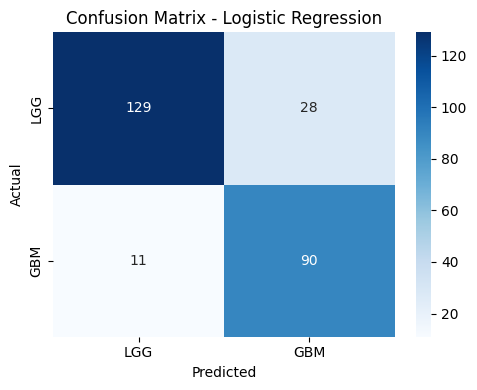

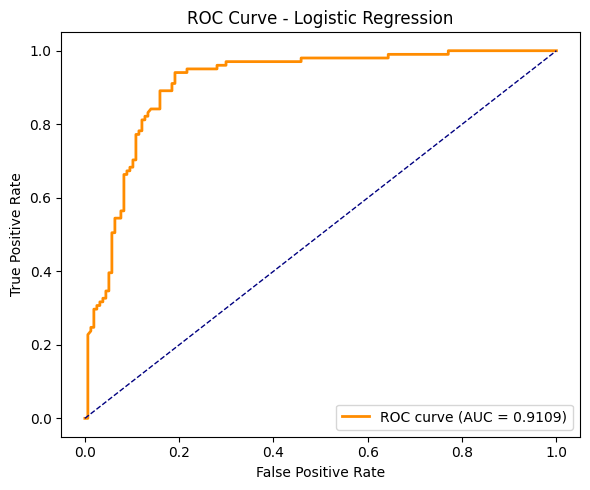

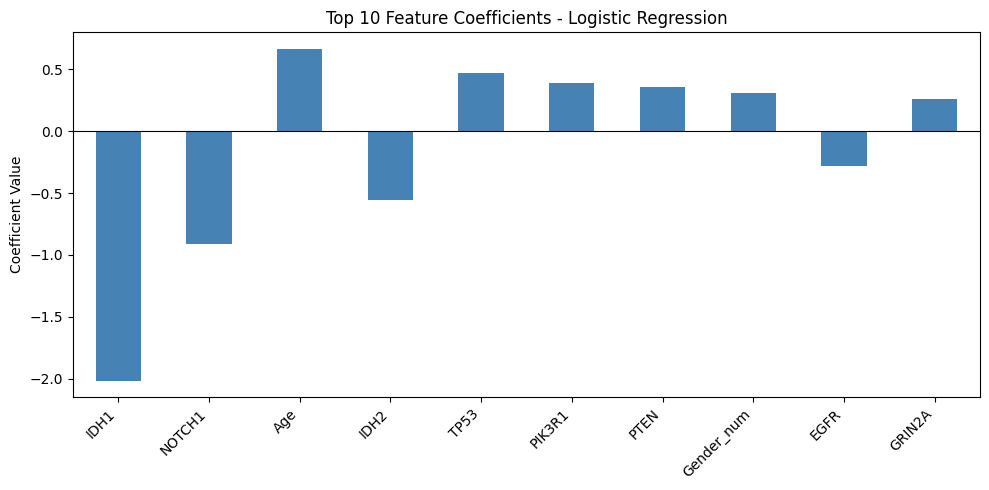

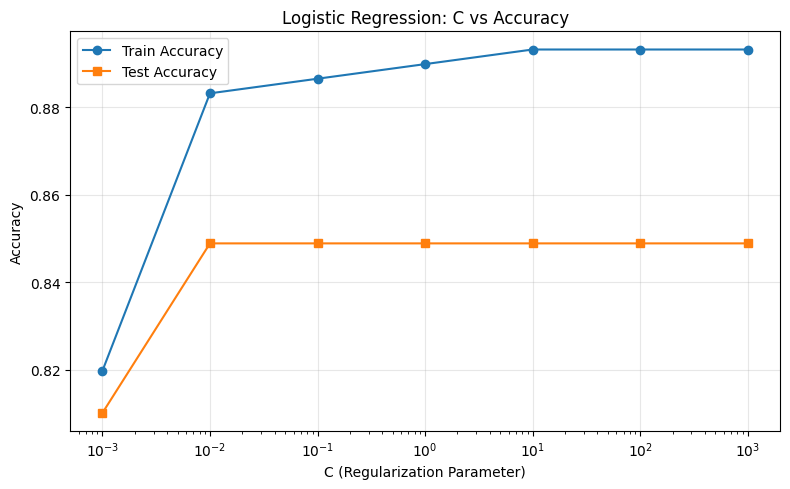

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler

# ── Helper & constants ──────────────────────────────────────────
def parse_age(s):
    m = re.search(r'(\d+)\s*years?', str(s))
    return int(m.group(1)) if m else None

mut_cols = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
            'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
            'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']

# ── Load & Preprocess ───────────────────────────────────────────
df = pd.read_csv("TCGA_GBM_LGG_Mutations_all.csv")
df['Age'] = df['Age_at_diagnosis'].apply(parse_age)
for c in mut_cols:
    df[c] = (df[c] == 'MUTATED').astype(int)
df['Gender_num'] = (df['Gender'] == 'Male').astype(int)
df['target'] = (df['Grade'] == 'GBM').astype(int)
df = df.dropna(subset=['Age'])
print(f"Dataset shape: {df.shape}")

# ── Train / Test Split ──────────────────────────────────────────
feature_cols = mut_cols + ['Age', 'Gender_num']
X = df[feature_cols]
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=101)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")

# ── Train Logistic Regression ───────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
preds = lr.predict(X_test)
proba = lr.predict_proba(X_test)[:,1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))
print("\nClassification Report:")
print(classification_report(y_test, preds))
print("Accuracy:", round(accuracy_score(y_test, preds), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))

# ── Confusion Matrix Heatmap ────────────────────────────────────
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d',
            cmap='Blues', xticklabels=['LGG','GBM'], yticklabels=['LGG','GBM'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ── ROC Curve ───────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, proba)
auc_score = roc_auc_score(y_test, proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ── Coefficients (Feature Importance) ──────────────────────────
coef_series = pd.Series(lr.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)
coef_series.head(10).plot(kind='bar', color='steelblue', figsize=(10, 5))
plt.title('Top 10 Feature Coefficients - Logistic Regression')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# ── Regularization: C vs Accuracy ──────────────────────────────
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_accs, test_accs = [], []
for c in C_values:
    m = LogisticRegression(C=c, max_iter=1000, random_state=42)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.semilogx(C_values, train_accs, label='Train Accuracy', marker='o')
plt.semilogx(C_values, test_accs, label='Test Accuracy', marker='s')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Accuracy')
plt.title('Logistic Regression: C vs Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()